<a href="https://colab.research.google.com/github/hadeswithming23/DeepLearning/blob/main/GroupG_DLI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Libraries

In [33]:
# Basic utilities
import time
import random
from typing import List

# Data handling
import numpy as np
import pandas as pd
import joblib

# Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Feature selection
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Model selection and hyperparameter tuning
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
)

# Handling class imbalance
from sklearn.utils.class_weight import compute_class_weight

# Machine learning models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier
import lightgbm as lgb
from xgboost import XGBClassifier

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, models

# Statistical distributions
from scipy.stats import randint, uniform

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Pandas display options
pd.set_option("display.float_format", "{:.3f}".format)

# Matplotlib defaults
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,       # makes plots more readable
    "grid.alpha": 0.3        # subtle grid lines
})

# 2. Read Dataset

In [34]:
# Load dataset
raw_df = pd.read_csv("https://raw.githubusercontent.com/hadeswithming23/DeepLearning/main/KDDTrain%2B.txt")

# Create a working copy to avoid modifying the raw data
df = raw_df.copy(deep=True)

# Preview the first rows
df.head()

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,...,0.000,0.600,0.880,0.000,0.000,0.000,0.000,0.000,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.100,0.050,0.000,0.000,1.000,1.000,0.000,0.000,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.000,0.000,0.030,0.040,0.030,0.010,0.000,0.010,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.070,0.070,0.000,0.000,0.000,0.000,1.000,1.000,neptune,21


## 2.1 Add Columns Names

In [35]:
# Define column names for the KDD dataset
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "attack", "level"
]

# Load dataset with column names directly
df = pd.read_csv("https://raw.githubusercontent.com/hadeswithming23/DeepLearning/main/KDDTrain%2B.txt", names=columns)

# Preview
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.170,0.030,0.170,0.000,0.000,0.000,0.050,0.000,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.000,0.600,0.880,0.000,0.000,0.000,0.000,0.000,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.100,0.050,0.000,0.000,1.000,1.000,0.000,0.000,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.000,0.000,0.030,0.040,0.030,0.010,0.000,0.010,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,normal,21


## 2.2 Dataset Insights

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [37]:
# Statistical summary
print("\nSummary stats:")
print(df.describe().T)


Summary stats:
                                 count      mean         std   min    25%  \
duration                    125973.000   287.145    2604.515 0.000  0.000   
src_bytes                   125973.000 45566.743 5870331.182 0.000  0.000   
dst_bytes                   125973.000 19779.114 4021269.151 0.000  0.000   
land                        125973.000     0.000       0.014 0.000  0.000   
wrong_fragment              125973.000     0.023       0.254 0.000  0.000   
urgent                      125973.000     0.000       0.014 0.000  0.000   
hot                         125973.000     0.204       2.150 0.000  0.000   
num_failed_logins           125973.000     0.001       0.045 0.000  0.000   
logged_in                   125973.000     0.396       0.489 0.000  0.000   
num_compromised             125973.000     0.279      23.942 0.000  0.000   
root_shell                  125973.000     0.001       0.037 0.000  0.000   
su_attempted                125973.000     0.001       0.045

# 3.0 Data Cleaning

## 3.1 Null Values

In [38]:
print("Missing values:\n", df.isnull().sum().sum())

Missing values:
 0


## 3.2 Duplicates

In [39]:
# Display duplicate rows (if any)
duplicates = df[df.duplicated()]
print(f"Number of duplicate rows: {len(duplicates)}")

if not duplicates.empty:
    display(duplicates.head())

Number of duplicate rows: 0


## 3.3 Outliers

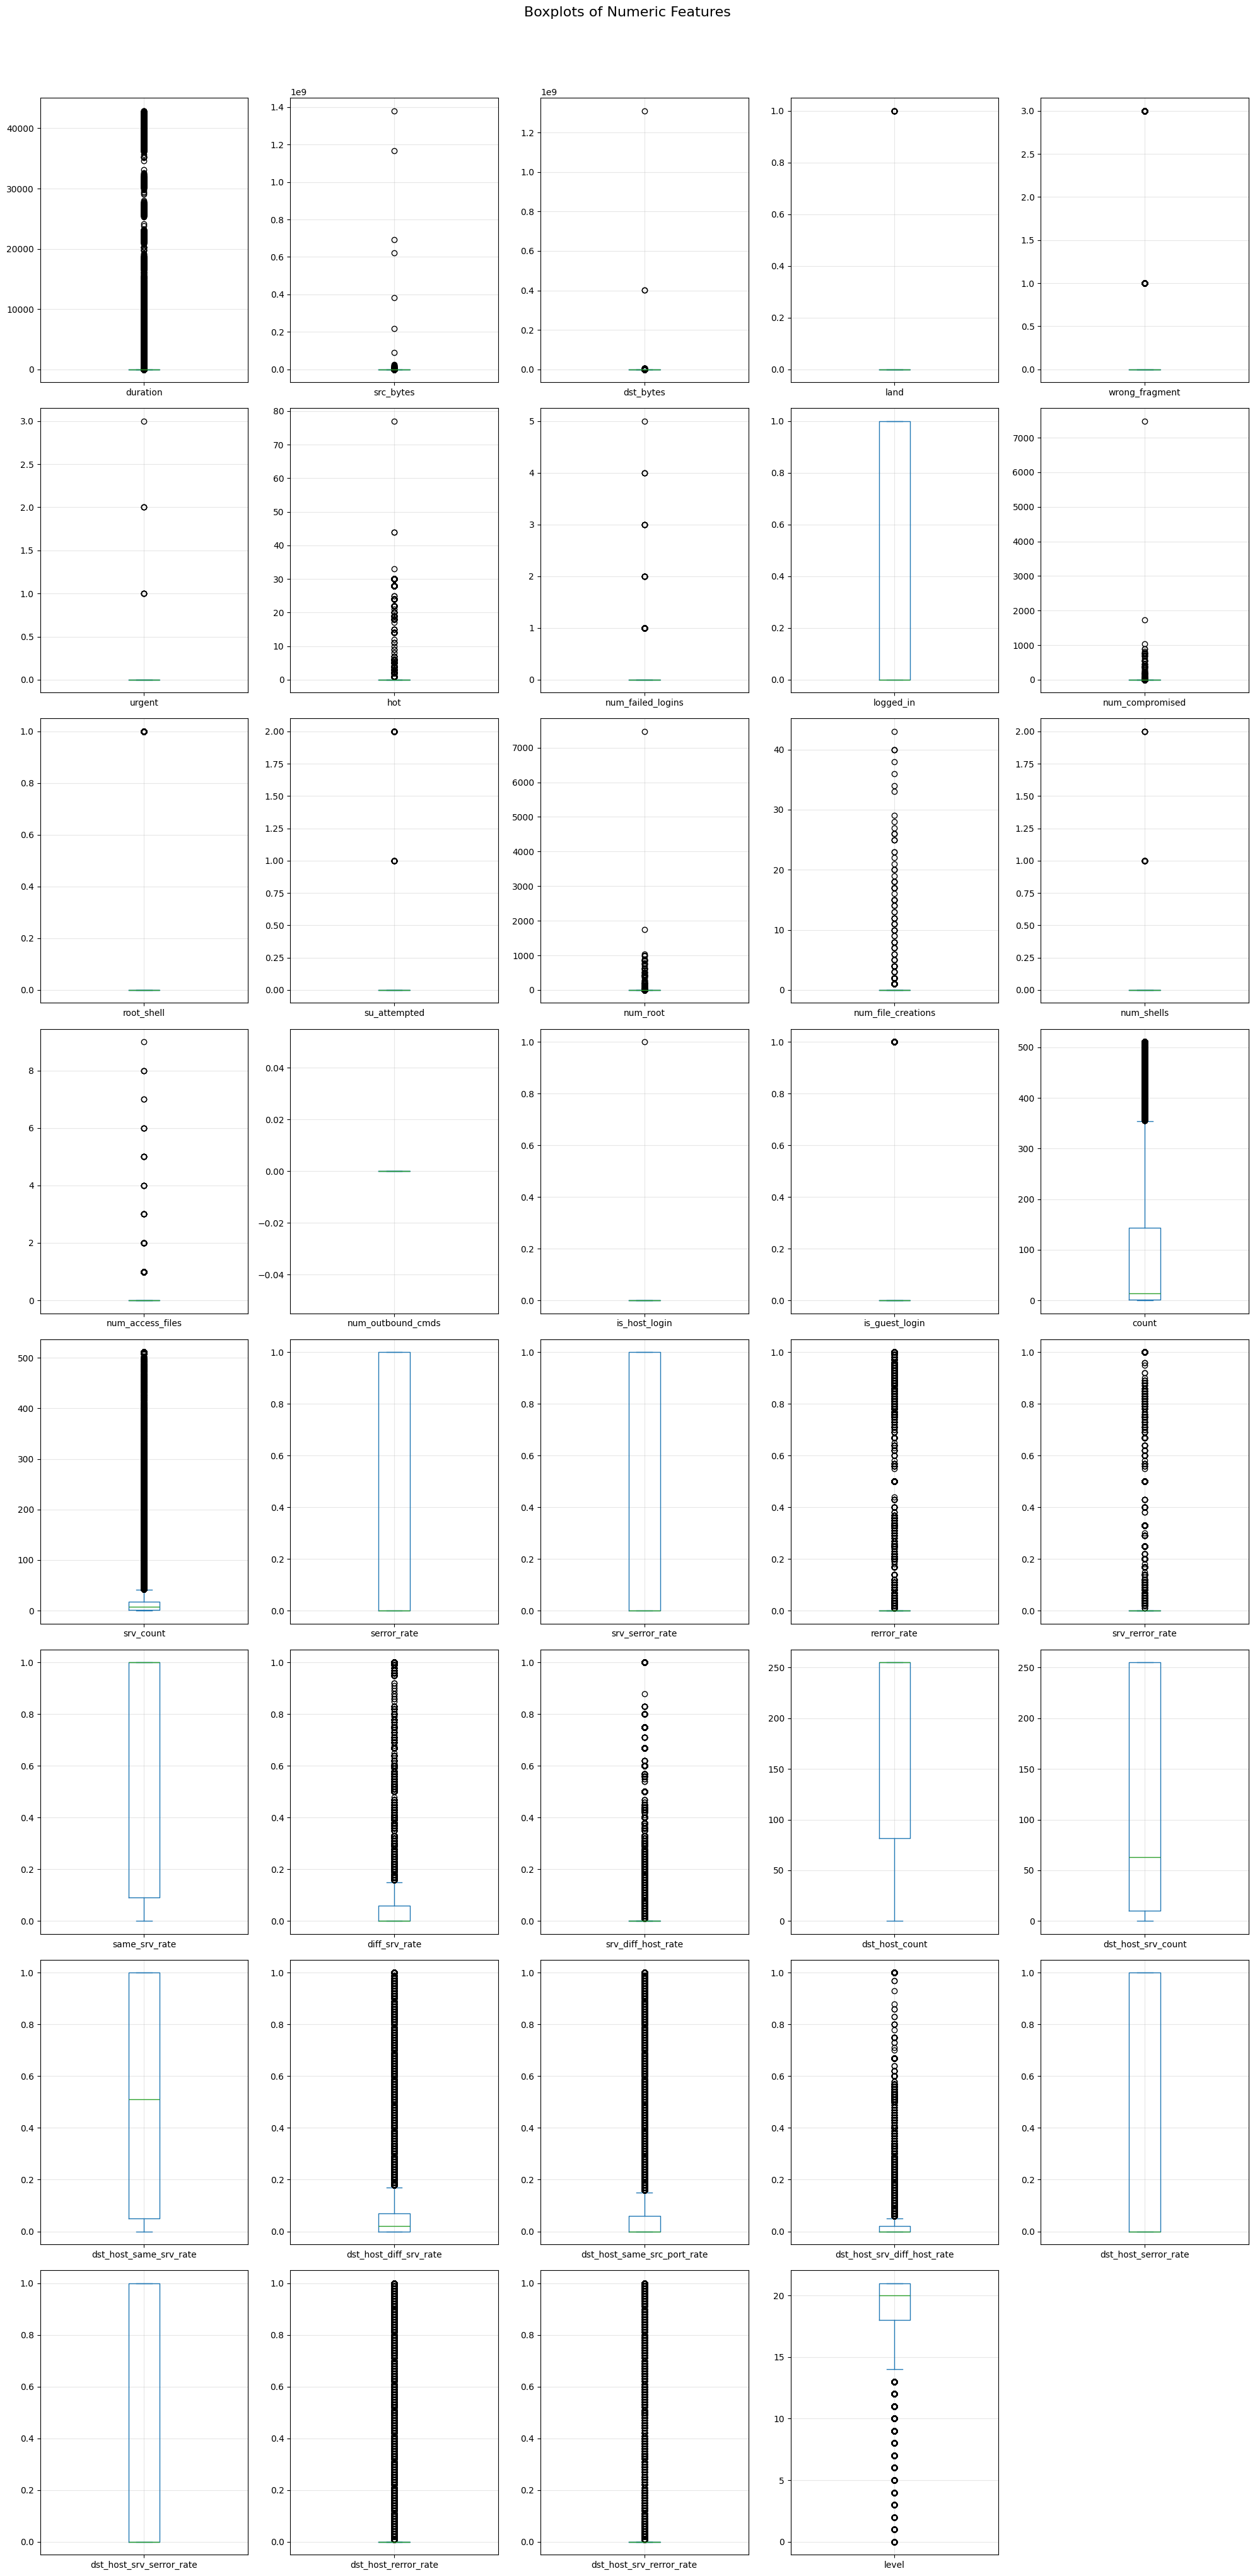

In [40]:
# Boxplots for all numerical features
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_cols].plot(
    kind="box",
    subplots=True,
    layout=(len(numeric_cols)//5 + 1, 5),  # auto-adjust rows
    figsize=(20, 40),
    sharex=False,
    sharey=False
)

plt.suptitle("Boxplots of Numeric Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## 3.4 Classifying Attacks In "attack" Column Into attack Or normal

In [41]:
df['attack'] = np.where(df['attack'] == "normal", "normal", "attack")

df['attack'].unique()

array(['normal', 'attack'], dtype=object)

# 4.0 EDA - Visualisations

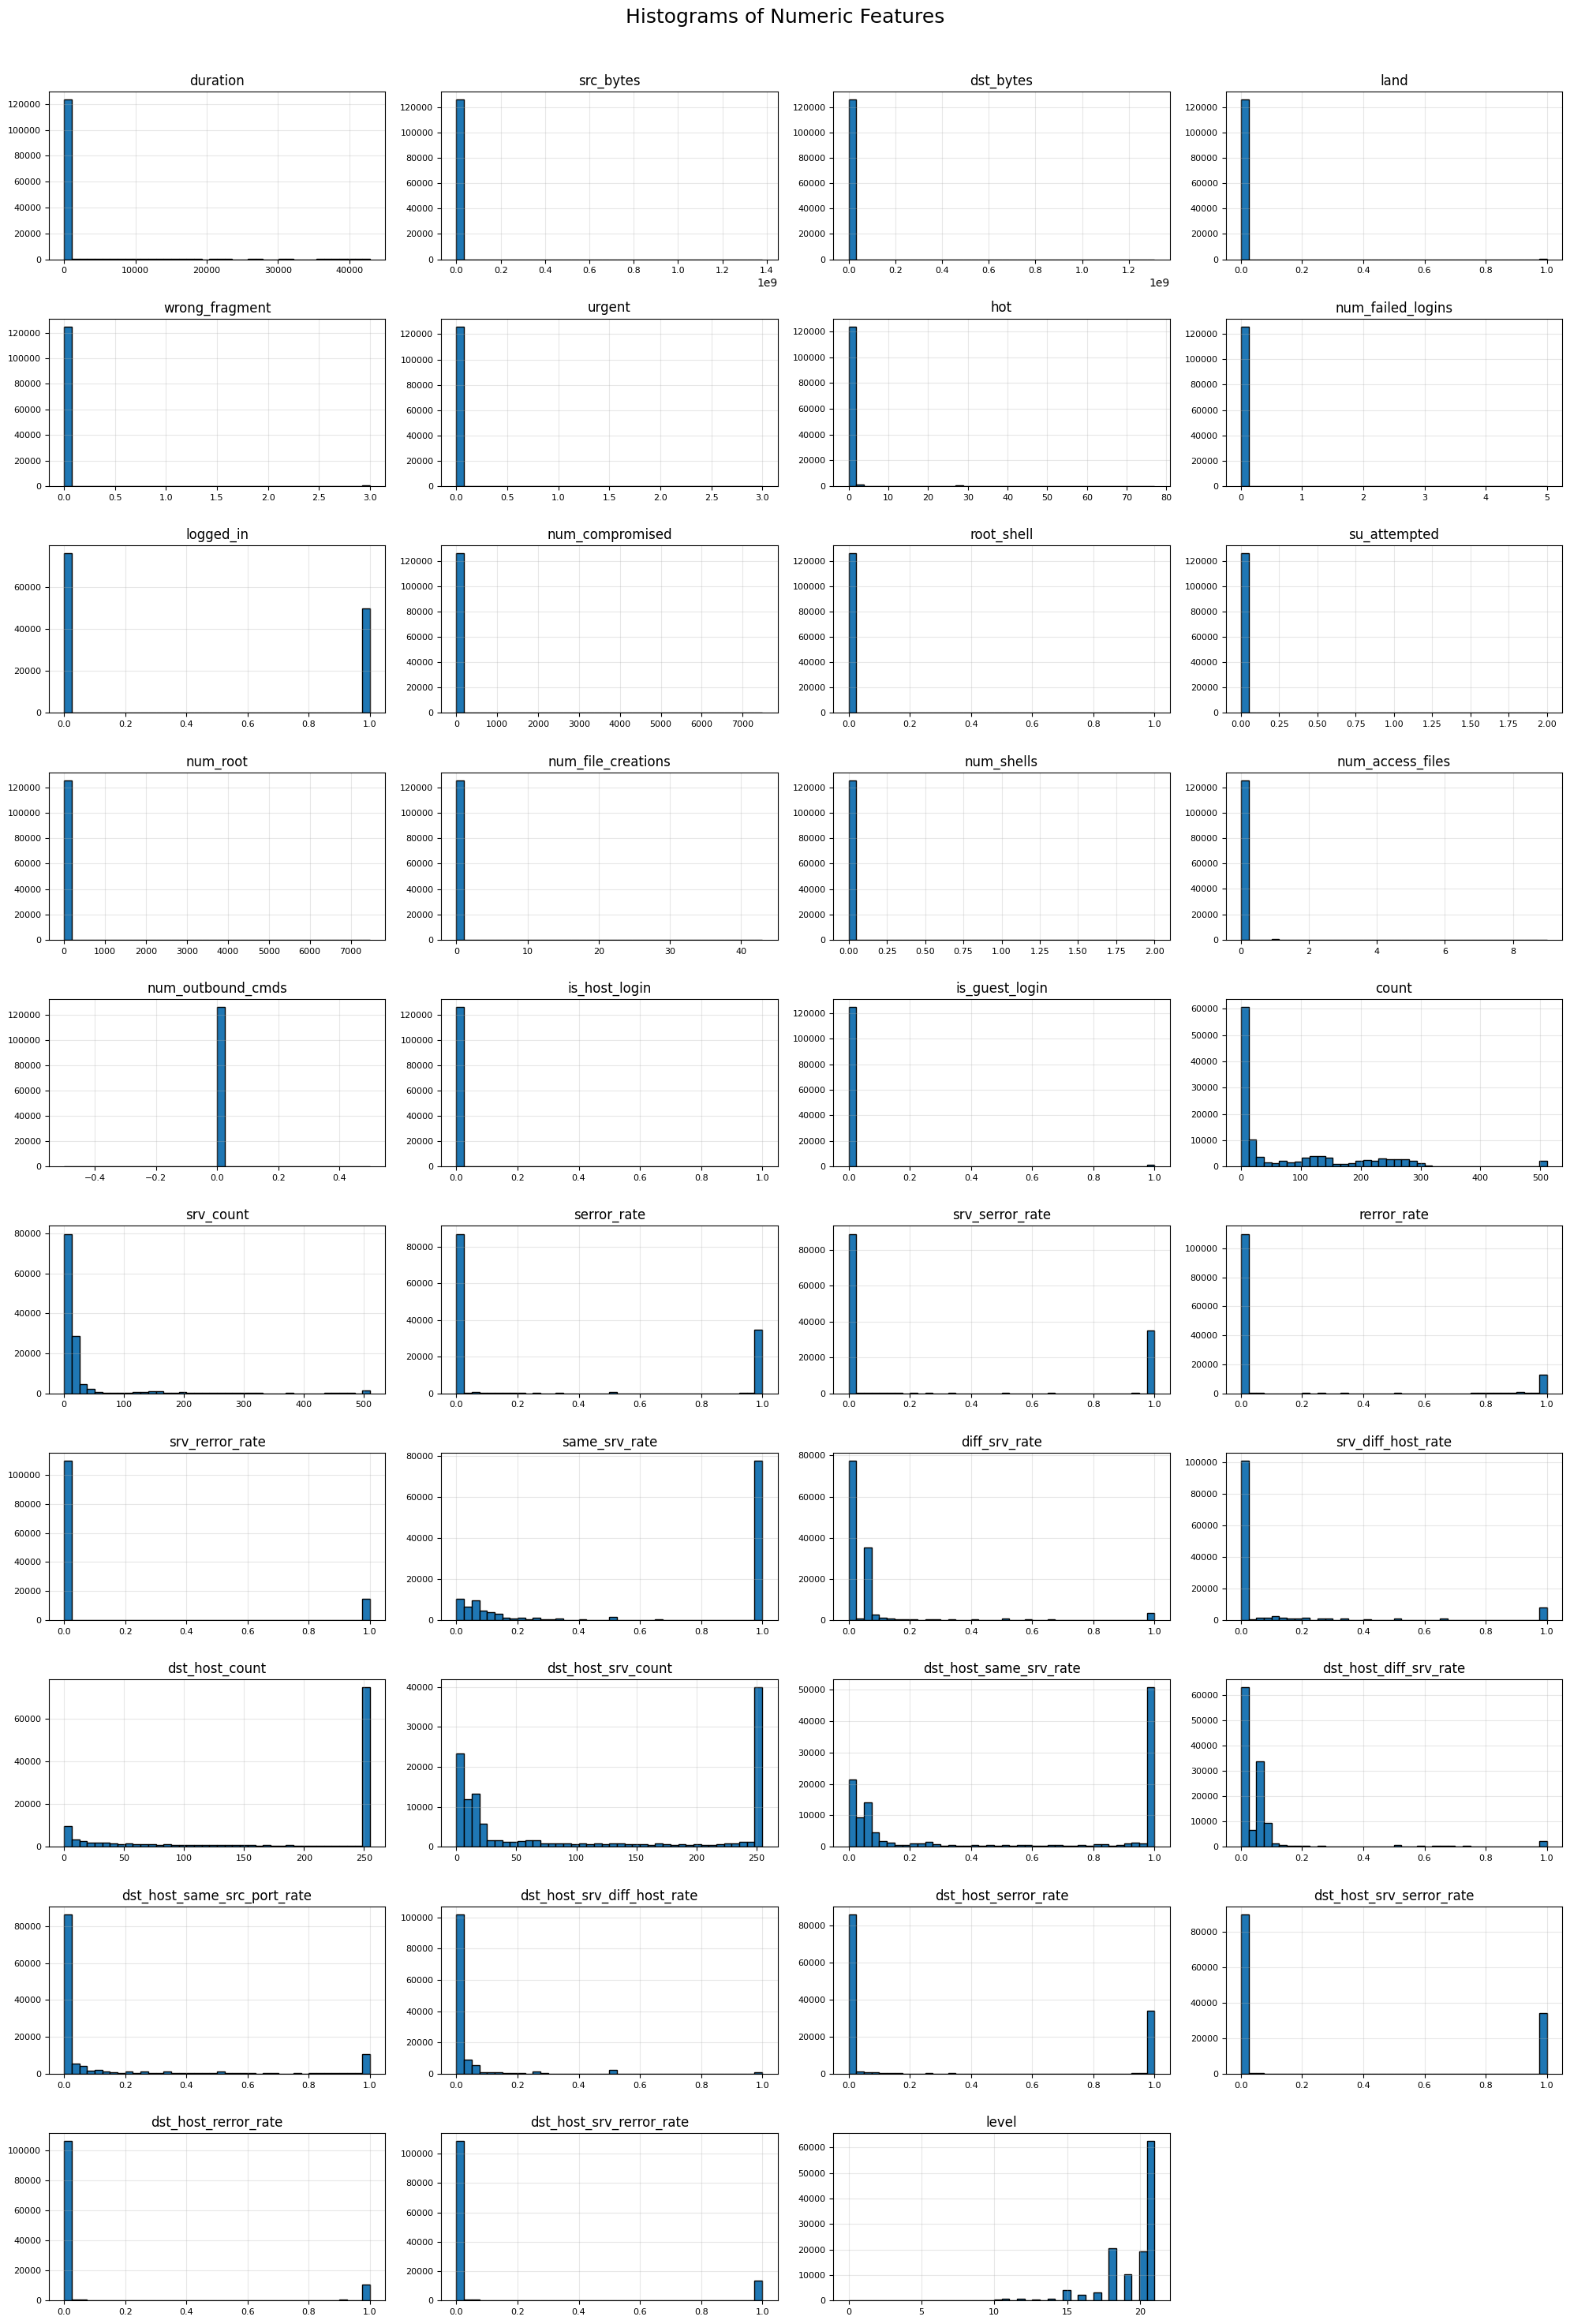

In [42]:
# Histograms for all numeric features
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_cols].hist(
    bins=40,             # number of bins
    figsize=(20, 30),    # figure size
    edgecolor="black",   # better visibility
    layout=(len(numeric_cols)//4 + 1, 4),  # auto layout in 4 columns
    xlabelsize=8, ylabelsize=8
)

plt.suptitle("Histograms of Numeric Features", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## 4.1 Target Variable Distribution

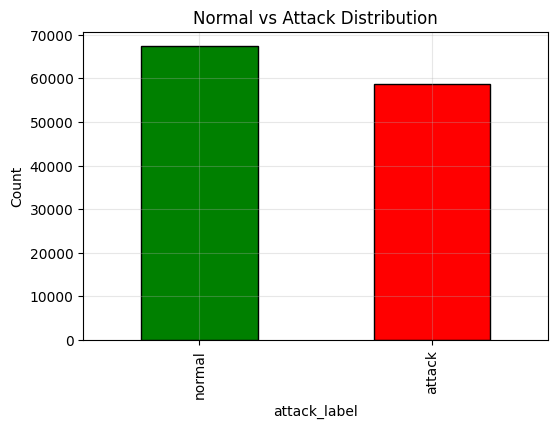


Attack types distribution:
attack
normal    67343
attack    58630
Name: count, dtype: int64


In [43]:
plot_df = df.copy()
plot_df['attack_label'] = df['attack'].apply(lambda x: "normal" if x == "normal" else "attack")

plt.figure(figsize=(6,4))
plot_df['attack_label'].value_counts().plot(kind="bar", color=["green","red"], edgecolor="black")
plt.title("Normal vs Attack Distribution")
plt.ylabel("Count")
plt.show()

print("\nAttack types distribution:")
print(df['attack'].value_counts().head(10))

## 4.2 Protocol, Service, Flag Analysis

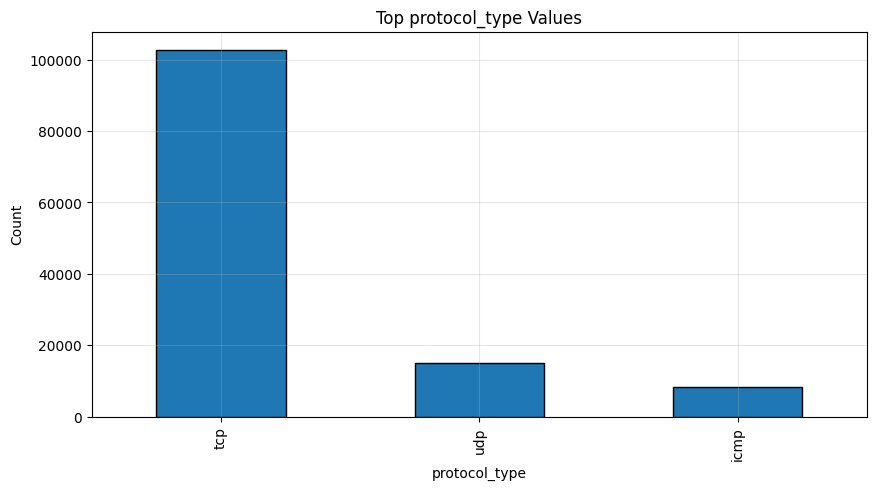

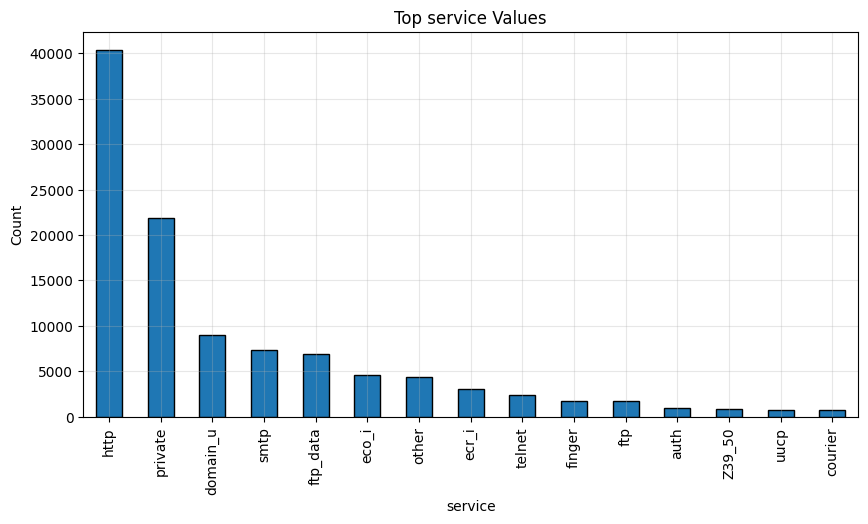

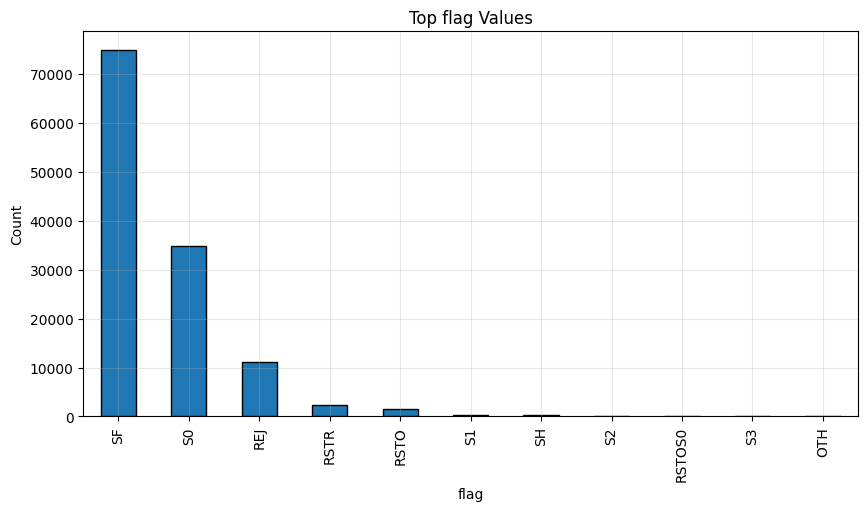

In [44]:
categorical_cols = ['protocol_type', 'service', 'flag']

for col in categorical_cols:
    plt.figure(figsize=(10,5))
    df[col].value_counts().head(15).plot(kind="bar", edgecolor="black")
    plt.title(f"Top {col} Values")
    plt.ylabel("Count")
    plt.show()

## 4.3 Attack vs Normal by Protocol

<Figure size 800x500 with 0 Axes>

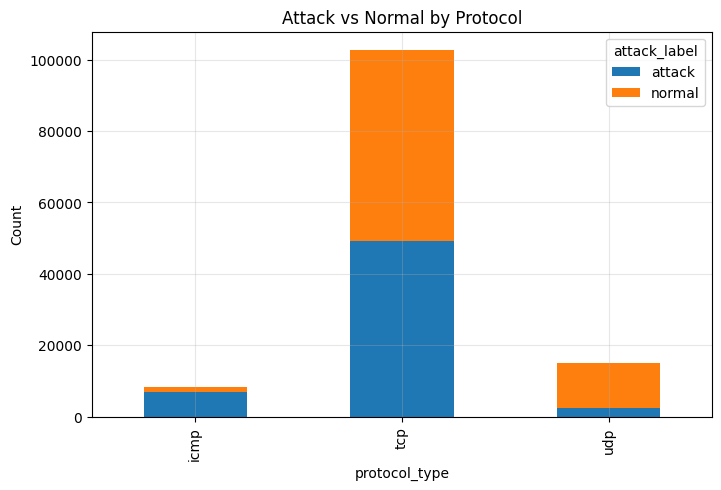

In [45]:
plt.figure(figsize=(8,5))
pd.crosstab(plot_df['protocol_type'], plot_df['attack_label']).plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Attack vs Normal by Protocol")
plt.ylabel("Count")
plt.show()

## 4.4 Feature Behavior for Attacks



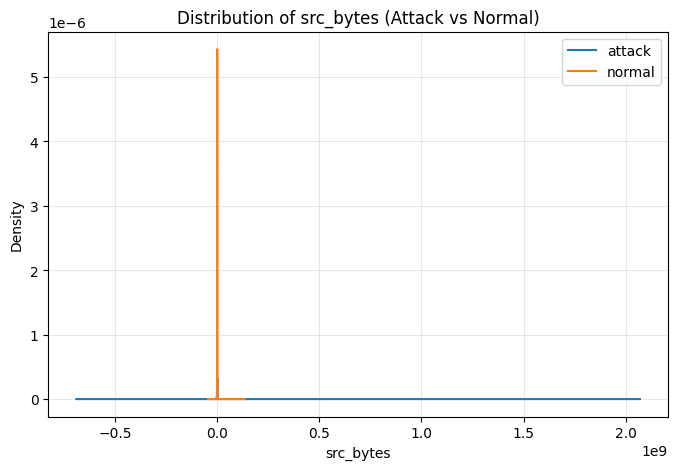

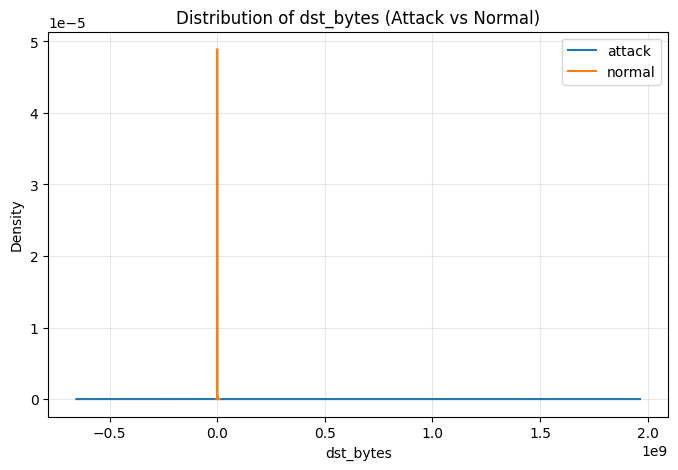

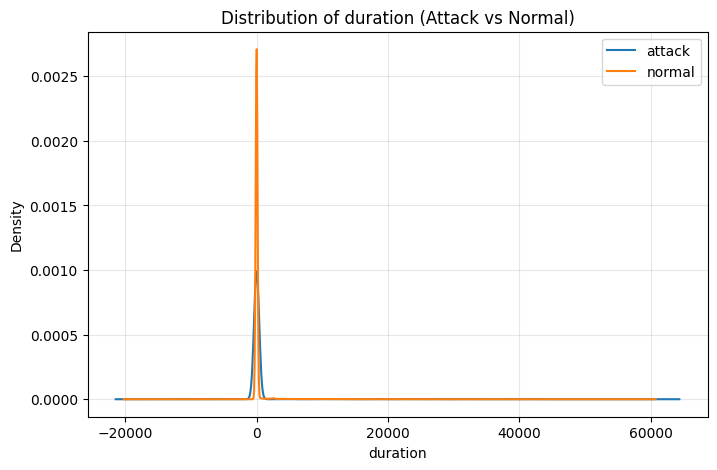

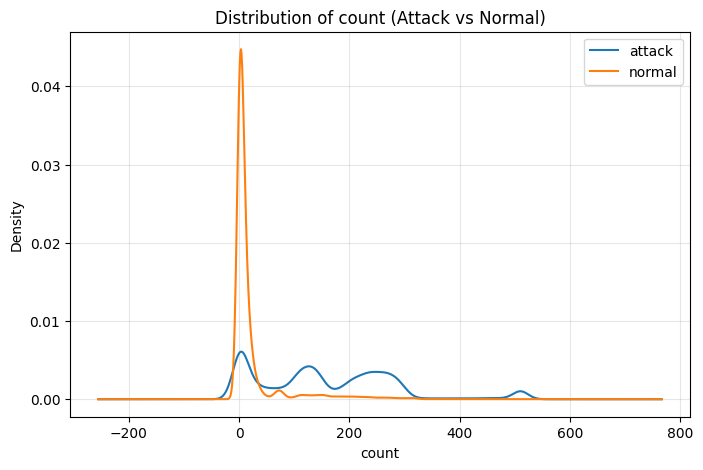

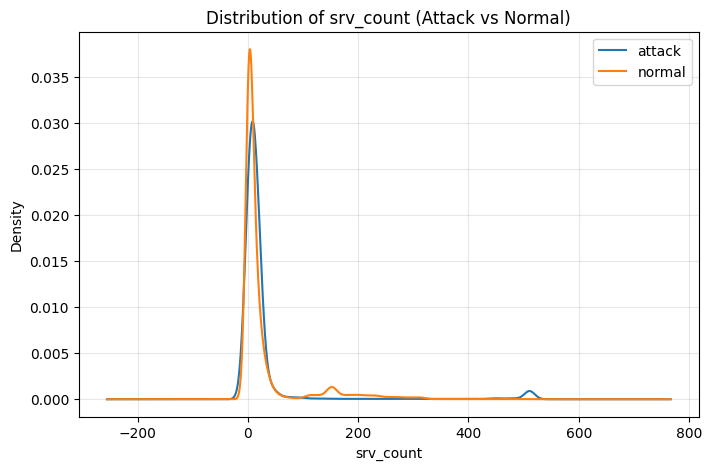

In [46]:
numeric_cols = ['src_bytes','dst_bytes','duration','count','srv_count']

for col in numeric_cols:
    plt.figure(figsize=(8,5))
    plot_df.groupby('attack_label')[col].plot(kind="kde", legend=True)
    plt.title(f"Distribution of {col} (Attack vs Normal)")
    plt.xlabel(col)
    plt.show()

## 4.5 Correlation Heatmap (Key Features)

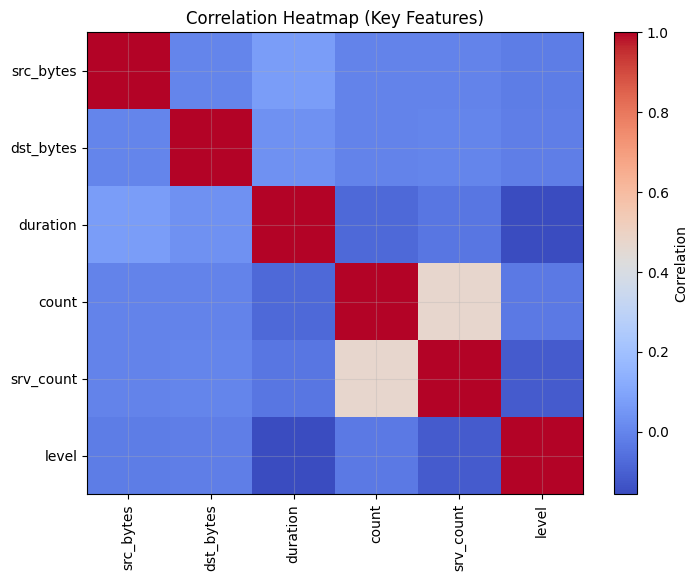

In [47]:
corr = df[numeric_cols + ['level']].corr()
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(np.arange(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(np.arange(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap (Key Features)")
plt.show()

# 5.0 Data Preprocessing

## 5.1 Encode Target Variable

In [48]:
# Attack: normal=0, attack=1
le = LabelEncoder()
df['attack_binary'] = le.fit_transform(df['attack'].apply(lambda x: "normal" if x == "normal" else "attack"))

## 5.2 Encode Categorical Features

In [49]:
# One-Hot for protocol_type and flag (small categories)
df = pd.get_dummies(df, columns=['protocol_type', 'flag'], drop_first=True)

# Frequency Encoding for service (many categories)
service_counts = df['service'].value_counts().to_dict()
df['service_encoded'] = df['service'].map(service_counts)
df = df.drop(columns=['service'])

## 5.3 Train Test Split

In [50]:
X = df.drop(columns=['attack','attack_binary'])  # features
y = df['attack_binary']                           # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (88181, 52)
Test shape: (37792, 52)


## 5.4 Feature Engineering: Mutual Information

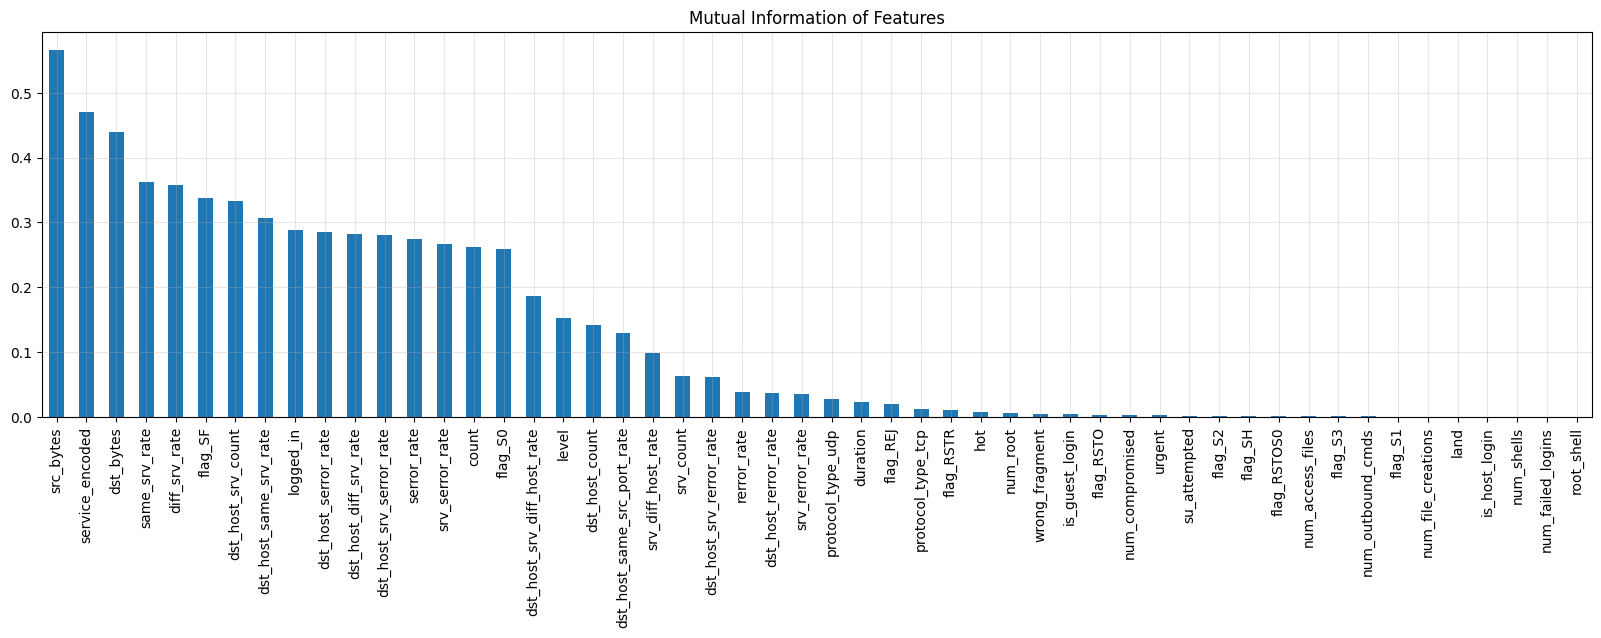

Top features by mutual information:

src_bytes                     0.565
service_encoded               0.470
dst_bytes                     0.440
same_srv_rate                 0.362
diff_srv_rate                 0.357
flag_SF                       0.338
dst_host_srv_count            0.332
dst_host_same_srv_rate        0.307
logged_in                     0.288
dst_host_serror_rate          0.285
dst_host_diff_srv_rate        0.282
dst_host_srv_serror_rate      0.280
serror_rate                   0.274
srv_serror_rate               0.267
count                         0.262
flag_S0                       0.259
dst_host_srv_diff_host_rate   0.186
level                         0.153
dst_host_count                0.141
dst_host_same_src_port_rate   0.129
dtype: float64


In [51]:
# Calculate mutual information scores
mutual_info = mutual_info_classif(X_train, y_train)
mutual_info = pd.Series(mutual_info, index=X_train.columns)

# Sort and plot
mutual_info = mutual_info.sort_values(ascending=False)
plt.figure(figsize=(20, 5))
mutual_info.plot(kind="bar")
plt.title("Mutual Information of Features")
plt.show()

# Display top features
print("Top features by mutual information:\n")
print(mutual_info.head(20))

## 5.5 Feature Selection: SelectKBest

In [52]:
# Select top k features
k = 30
selector = SelectKBest(mutual_info_classif, k=k)
selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.get_support()]
print(f"\nSelected Top {k} Features:\n", list(selected_features))

# For modeling, keep only top 15 features (to balance size vs. performance)
top_n = 30
selected_features_final = list(selected_features[:top_n])
print(f"\nUsing Top {top_n} Features:\n", selected_features_final)

# Reduce train/test sets
X_train_sel = X_train[selected_features_final]
X_test_sel = X_test[selected_features_final]


Selected Top 30 Features:
 ['duration', 'src_bytes', 'dst_bytes', 'logged_in', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'level', 'protocol_type_udp', 'flag_REJ', 'flag_RSTR', 'flag_S0', 'flag_SF', 'service_encoded']

Using Top 30 Features:
 ['duration', 'src_bytes', 'dst_bytes', 'logged_in', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serro

## 5.6 Feature Scaling

In [53]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)  # Prevents data leakage
joblib.dump(scaler, "scaler.pkl")

print("Final Train Shape:", X_train_scaled.shape)
print("Final Test Shape:", X_test_scaled.shape)

Final Train Shape: (88181, 30)
Final Test Shape: (37792, 30)


# 6.0 Model Builiding

In [54]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    """Train model, evaluate, and return performance metrics."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred, average="weighted")
    }

    return metrics, classification_report(y_test, y_pred, digits=5), confusion_matrix(y_test, y_pred)

## 6.3 Low Sze Shun TP065472

In [72]:
# 6.0 Model Building (Updated with improvements)
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import StackingClassifier

print("="*60)
print("Optimized DT + LightGBM + Stacking Ensemble".center(60))
print("="*60)

# -------------------------------
# Utility: Train + Evaluate Model
# -------------------------------
def evaluate_model(model, X_train, y_train, X_test, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    preds = model.predict(X_test)
    return {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),  # binary
        "Recall": recall_score(y_test, preds, zero_division=0),        # binary
        "F1-Score": f1_score(y_test, preds, zero_division=0),          # binary
        "Training_Time": elapsed
    }, model

# -------------------------------
# Apply SMOTE to balance classes
# -------------------------------
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print(f"Balanced training set shape: {X_train_bal.shape}, {y_train_bal.shape}")

# -------------------------------
# Class weights for imbalance
# -------------------------------
classes = np.unique(y_train_bal)
weights = compute_class_weight("balanced", classes=classes, y=y_train_bal)
class_weight_dict = dict(zip(classes, weights))

# -------------------------------
# Step 1: Base Decision Tree
# -------------------------------
dt_base = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=25,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion="gini"
)
dt_metrics, dt_fitted = evaluate_model(dt_base, X_train_bal, y_train_bal, X_test_scaled, y_test)

# -------------------------------
# Step 2: LightGBM Hyperparameter Search
# -------------------------------
param_dist = {
    "num_leaves": randint(31, 255),
    "max_depth": randint(4, 12),
    "learning_rate": uniform(0.01, 0.1),
    "n_estimators": randint(300, 1200),
    "min_child_samples": randint(10, 60),
    "subsample": uniform(0.6, 0.3),
    "colsample_bytree": uniform(0.6, 0.4),
    "reg_alpha": uniform(0.0, 1.0),
    "reg_lambda": uniform(0.0, 1.0),
    "min_data_in_leaf": randint(20, 200),
    "feature_fraction": uniform(0.0, 1.0)
}

lgb_base = lgb.LGBMClassifier(
    objective="binary",
    class_weight=class_weight_dict,
    boosting_type="gbdt",
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

search = RandomizedSearchCV(
    lgb_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

search.fit(X_train_bal, y_train_bal)
best_params = search.best_params_

print("\n=== Best Hyperparameters Found ===")
print(f"Best CV Score (F1-weighted): {search.best_score_:.8f}")
for param, value in best_params.items():
    print(f"{param}: {value}")

# -------------------------------
# Step 3: Train final LightGBM with Early Stopping (fixed)
# -------------------------------
from lightgbm import early_stopping, log_evaluation

lgb_final = lgb.LGBMClassifier(
    objective="binary",
    class_weight=class_weight_dict,
    boosting_type="gbdt",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    **best_params
)

lgb_final.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test_scaled, y_test)],
    eval_metric="binary_error",
    callbacks=[early_stopping(stopping_rounds=50), log_evaluation(50)]
)

lgb_metrics, lgb_fitted = evaluate_model(lgb_final, X_train_bal, y_train_bal, X_test_scaled, y_test)

# -------------------------------
# Step 4: Stacking Ensemble
# -------------------------------
stack_ensemble = StackingClassifier(
    estimators=[("dt", dt_fitted), ("lgb", lgb_fitted)],
    final_estimator=lgb.LGBMClassifier(
        objective="binary",
        n_estimators=500, learning_rate=0.05, random_state=42
    ),
    cv=3,
    n_jobs=-1
)

ens_metrics, ens_fitted = evaluate_model(stack_ensemble, X_train_bal, y_train_bal, X_test_scaled, y_test)

# --- Print Results ---
print("\n=== Base Decision Tree Results ===")
print(dt_metrics)

print("\n=== Hypertuned LightGBM Results ===")
print(lgb_metrics)

print("\n=== Stacking Ensemble Results ===")
print(ens_metrics)

# Classification report for ensemble
ens_preds = ens_fitted.predict(X_test_scaled)
print("\n=== Ensemble Classification Report ===")
print(classification_report(y_test, ens_preds, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, ens_preds)
print("\n=== Confusion Matrix ===")
print(cm)

# -------------------------------
# Create DataFrame with all 3 models' metrics
# -------------------------------
low_df = pd.DataFrame({
    'Model': ['Base Decision Tree', 'Hypertuned LightGBM', 'Stacking Ensemble (DT + LGBM)'],
    'Accuracy': [dt_metrics['Accuracy'], lgb_metrics['Accuracy'], ens_metrics['Accuracy']],
    'Precision': [dt_metrics['Precision'], lgb_metrics['Precision'], ens_metrics['Precision']],
    'Recall': [dt_metrics['Recall'], lgb_metrics['Recall'], ens_metrics['Recall']],
    'F1-Score': [dt_metrics['F1-Score'], lgb_metrics['F1-Score'], ens_metrics['F1-Score']],
    'Training_Time': [dt_metrics['Training_Time'], lgb_metrics['Training_Time'], ens_metrics['Training_Time']]
})

print("\n=== All Models Comparison (low_df) ===")
print(low_df.round(8))

# -------------------------------
# Save Final Model
# -------------------------------
joblib.dump(ens_fitted, "low_model.pkl")
print("\n🏆 Final Stacking Ensemble model saved as low_model.pkl")


        Optimized DT + LightGBM + Stacking Ensemble         
Balanced training set shape: (94280, 30), (94280,)

=== Best Hyperparameters Found ===
Best CV Score (F1-weighted): 0.99949087
colsample_bytree: 0.749816047538945
feature_fraction: 0.9507143064099162
learning_rate: 0.0831993941811405
max_depth: 8
min_child_samples: 30
min_data_in_leaf: 122
n_estimators: 421
num_leaves: 241
reg_alpha: 0.09997491581800289
reg_lambda: 0.45924889196586716
subsample: 0.7001125833417066
Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_error: 0.00137595	valid_0's binary_logloss: 0.0122142
[100]	valid_0's binary_error: 0.000635055	valid_0's binary_logloss: 0.00222615
[150]	valid_0's binary_error: 0.000343988	valid_0's binary_logloss: 0.00122132
[200]	valid_0's binary_error: 0.000317528	valid_0's binary_logloss: 0.000996434
[250]	valid_0's binary_error: 0.000291067	valid_0's binary_logloss: 0.000894703
Early stopping, best iteration is:
[247]	valid_0's binary_error: 0